# Feature Engineering — Corrected Notebook

This is a corrected version of your Feature Engineering notebook. It keeps the same
overall structure (Null Values → Outliers → Preprocessing/Encoding → Transformation → Scaling)
but fixes the bugs and the conceptually wrong steps that were in the original.

**A synthetic dataset is generated below** (same columns as the classic Loan Prediction
dataset your notebook used) so this notebook runs end-to-end on its own. Replace the
"Load data" cell with `pd.read_csv("loan_approved.csv")` to use your real file — everything
downstream works the same way.

At the very end there is a section **"What was wrong in the original notebook"** that maps
every fix back to the specific cell/section in your original file so you can correct it there.

## 1. Imports

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from scipy.stats import boxcox

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None) # is a Pandas display setting. It tells Pandas:

# "When displaying a DataFrame, show all columns. Don't hide any because there are too many."

## 2. Load data

Swap this cell for `df = pd.read_csv("loan_approved.csv")` to use your real file.
The synthetic generator below intentionally includes: missing values in the same columns
your dataset had, some outliers in `ApplicantIncome`/`LoanAmount`, and — importantly —
**some `CoapplicantIncome` values equal to 0**, because that detail is what breaks the
log-transform step in the original notebook (see the notes at the bottom).

In [58]:
df = pd.read_csv("loan_approved.csv")

In [59]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


This code is creating a synthetic loan approval dataset with 614 rows. It is designed to look somewhat like the classic Loan Prediction / Loan Approval dataset, including missing values and outliers so you can practice preprocessing and feature engineering.
```
rng is a random-number generator from NumPy.

The 42 is the seed.

Why use 42?

Normally, random values change every time you run the code.

For example:

np.random.randint(1, 10, 5)

could give different values each time.

But:

rng = np.random.default_rng(42)

makes the randomness reproducible.

So whenever you run the code again, you'll get the same generated dataset.

Think:

42 = "Random, but please make it the same random every time."
___________________________________________________________________

Create 614 loan applicants.

Therefore, the DataFrame will have:

614 rows
___________________________________________________________________

Each item inside {} becomes a column.

___________________________________________________________________

Loan_ID: This generates IDs like:

LP000001
LP000002

range(1, n + 1)

Since:

n = 614

this becomes:

range(1, 615)

which gives:

1, 2, 3, ..., 614

str(i)

Converts the number into a string.

str(5)

becomes:

"5"
.zfill(6)

Adds zeros until the string has 6 characters.

"5".zfill(6)

becomes:

"000005"

Then:

f"LP{...}"

adds LP.

So:

f"LP{str(5).zfill(6)}"

becomes:

LP000005
___________________________________________________________________

Gender:

The probabilities are:

Value	Probability
Male	75%
Female	20%
Missing (None)	5%

size=n means:

Generate 614 values

So you'll get approximately:

~461 Male
~123 Female
~31 Missing

Not exactly those numbers because it's random.
___________________________________________________________________

ApplicantIncome: 

This generates applicant incomes using a Gamma distribution.

The important idea isn't the mathematical details yet.

You're basically saying:

Generate income values that have a realistic-looking, right-skewed distribution.

That's useful because real income data often isn't normally distributed.

For example, you might get:

2500
3200
4100
5200
7800
...

Then:

.round(0)

rounds the values to zero decimal places.

So:

4523.72

becomes:

4524
___________________________________________________________________

CoapplicantIncome: 

You're saying:

For about 40% of applicants, make the coapplicant income 0.

Why?

Because some loan applicants don't have a coapplicant.

rng.random(n)

Generates 614 random numbers between:

0 and 1

Then 

< 0.4

is True roughly 40% of the time.

means:

IF random number < 0.4
    → CoapplicantIncome = 0
ELSE
    → generate an income

So this column contains lots of zeros.

That's useful because you'll later see a distribution like:

0  0  0  0  1500  2300  2800 ...
___________________________________________________________________

LoanAmount:

Here you're using a normal distribution.

means approximately:

mean = 146
standard deviation = 45

So most loan amounts will be somewhere around 146, with variation around that value.

Then:

.round(0)

rounds the values.

And:

.clip(9)

prevents values from going below 9.

For example:

5  → 9
7  → 9
12 → 12
200 → 200

This prevents unrealistic negative/super-low loan amounts.

In [60]:
rng = np.random.default_rng(42)
n = 614

df = pd.DataFrame({
    "Loan_ID": [f"LP{str(i).zfill(6)}" for i in range(1, n + 1)],
    "Gender": rng.choice(["Male", "Female", None], size=n, p=[0.75, 0.20, 0.05]),
    "Married": rng.choice(["Yes", "No", None], size=n, p=[0.63, 0.34, 0.03]),
    "Dependents": rng.choice(["0", "1", "2", "3+", None], size=n, p=[0.55, 0.18, 0.15, 0.09, 0.03]),
    "Education": rng.choice(["Graduate", "Not Graduate"], size=n, p=[0.78, 0.22]),
    "Self_Employed": rng.choice(["No", "Yes", None], size=n, p=[0.75, 0.13, 0.12]),
    "ApplicantIncome": rng.gamma(3.0, 2200, size=n).round(0),
    "CoapplicantIncome": np.where(rng.random(n) < 0.4, 0.0, rng.gamma(2.0, 1200, size=n)).round(0),
    "LoanAmount": rng.normal(146, 45, size=n).round(0).clip(9),
    "Loan_Amount_Term": rng.choice([360.0, 180.0, 120.0, 300.0, None], size=n, p=[0.75, 0.1, 0.06, 0.06, 0.03]),
    "Credit_History": rng.choice([1.0, 0.0, None], size=n, p=[0.72, 0.14, 0.14]),
    "Property_Area": rng.choice(["Urban", "Semiurban", "Rural"], size=n),
})

# a few injected high-income outliers, like a real loan dataset would have
df.loc[df.sample(6, random_state=1).index, "ApplicantIncome"] = rng.integers(60000, 90000, size=6)
df.loc[df.sample(4, random_state=2).index, "LoanAmount"] = rng.integers(500, 700, size=4)

status_prob = 0.5 + 0.3 * (df["Credit_History"].fillna(1) == 1)
df["Loan_Status (Approved)"] = np.where(rng.random(n) < status_prob, "Y", "N")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP000001,Female,Yes,3+,Graduate,No,4746.0,0.0,122.0,120.0,1.0,Semiurban,Y
1,LP000002,Male,No,0,Not Graduate,No,8700.0,1129.0,99.0,360.0,None,Semiurban,Y
2,LP000003,Female,No,0,Graduate,No,1878.0,1223.0,135.0,None,1.0,Rural,Y
3,LP000004,Male,Yes,1,Graduate,No,4357.0,1152.0,196.0,360.0,0.0,Urban,Y
4,LP000005,Male,Yes,0,Graduate,Yes,10560.0,0.0,123.0,360.0,0.0,Urban,Y


## 3. First look at the data

Same as your original notebook: shape, dtypes, and a null-value count. Nothing changes here —
`.isnull()`, `.info()`, `.isna()`, `.notnull()` etc. were all used correctly in your version.

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  587 non-null    object 
 2   Married                 590 non-null    object 
 3   Dependents              593 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           542 non-null    object 
 6   ApplicantIncome         614 non-null    float64
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              614 non-null    float64
 9   Loan_Amount_Term        595 non-null    object 
 10  Credit_History          517 non-null    object 
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(3), object(10)
memory usage: 62.5+ KB


In [62]:
df.isnull().sum()

Loan_ID                    0
Gender                    27
Married                   24
Dependents                21
Education                  0
Self_Employed             72
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term          19
Credit_History            97
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

## 4. Drop the identifier column — do this *first*

`Loan_ID` is a unique identifier. Your own notebook's introduction says it correctly:
unique IDs are not predictive and will just overfit. But the code never actually drops it,
which is exactly why the very last cells of the original notebook crash with
`ValueError: could not convert string to float: 'LP001560'` — the scalers choke on it at the end.
Drop it right away, before any imputation/encoding/scaling.

In [63]:
df = df.drop(columns=["Loan_ID"])

In [64]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,Female,Yes,3+,Graduate,No,4746.0,0.0,122.0,120.0,1.0,Semiurban,Y
1,Male,No,0,Not Graduate,No,8700.0,1129.0,99.0,360.0,None,Semiurban,Y
2,Female,No,0,Graduate,No,1878.0,1223.0,135.0,None,1.0,Rural,Y
3,Male,Yes,1,Graduate,No,4357.0,1152.0,196.0,360.0,0.0,Urban,Y
4,Male,Yes,0,Graduate,Yes,10560.0,0.0,123.0,360.0,0.0,Urban,Y


## 5. Handling missing values — impute from statistics, not from a guess

**This is the biggest correction.** In the original notebook every missing value was
filled with a *hand-picked constant* — `"Male"`, `"Yes"`, `"No"`, `360.0`, `0.0`, `'0'` — chosen
by eyeballing the data rather than computed from it. That's not a real imputation strategy;
it just bakes in a guess (and a different analyst, or a slightly different sample, would
guess differently).

The standard, defensible approach:
- **Categorical columns** → impute with the **mode** (most frequent category).
- **Numeric columns that are roughly continuous** (`LoanAmount`) → impute with the **median**
  (robust to skew/outliers) — your original notebook actually did this one correctly.
- **Numeric columns that are really discrete/categorical-like** (`Loan_Amount_Term`,
  `Credit_History`) → impute with the **mode**, not an arbitrary number. Filling
  `Credit_History` with `0.0` silently assumes "no history," which is a modelling decision
  in disguise — use the mode unless you have a specific business reason to assume 0.

In [65]:
categorical_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Property_Area"]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# discrete-but-numeric columns -> mode
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0]).astype(float)
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0]).astype(float)

# continuous numeric column -> median (this part of the original was already correct)
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [66]:
df.isnull().sum()   # should all be zero now

Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

In [67]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,Female,Yes,3+,Graduate,No,4746.0,0.0,122.0,120.0,1.0,Semiurban,Y
1,Male,No,0,Not Graduate,No,8700.0,1129.0,99.0,360.0,1.0,Semiurban,Y
2,Female,No,0,Graduate,No,1878.0,1223.0,135.0,360.0,1.0,Rural,Y
3,Male,Yes,1,Graduate,No,4357.0,1152.0,196.0,360.0,0.0,Urban,Y
4,Male,Yes,0,Graduate,Yes,10560.0,0.0,123.0,360.0,0.0,Urban,Y


## 6. Outliers

Same detection method as your original (boxplots + IQR fences) — the concept explanation
in your notebook was fine. The fix is in *how the outliers are treated*:

- Your notebook **winsorized** `ApplicantIncome` and then, separately, **deleted rows**
  outside the IQR fences for `LoanAmount`. Mixing "cap" and "delete" strategies across
  columns isn't wrong by itself, but dropping rows on a small dataset throws away
  information (and rows) for no real benefit over capping. Below, both columns are treated
  the same way — **capped (winsorized) to the fences**, so no rows are lost.
- Also worth knowing: outlier bounds should strictly be *learned from the training set only*
  and then applied to the test set, to avoid leaking test-set statistics into training. For
  a single-dataset EDA pass like this it's common to do it before the split, but keep the
  leakage point in mind for a real production pipeline.

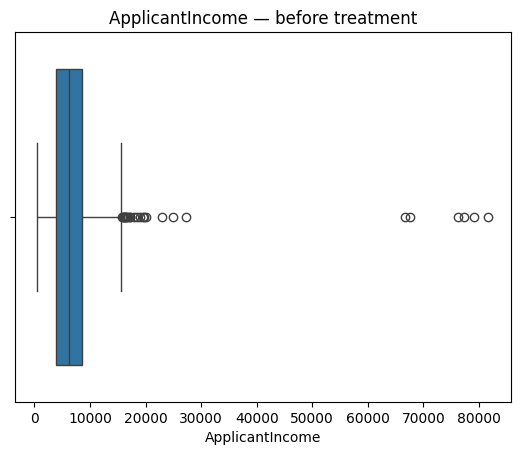

In [68]:
sns.boxplot(x=df["ApplicantIncome"], orient="h")
plt.title("ApplicantIncome — before treatment")
plt.show()

In [69]:
def iqr_cap(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in ["ApplicantIncome", "LoanAmount"]:
    df[col] = iqr_cap(df[col])

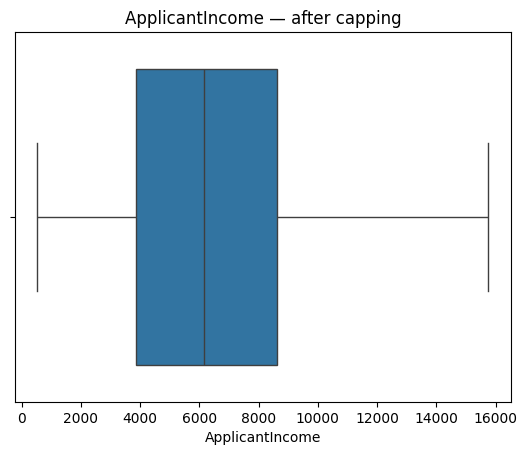

In [70]:
sns.boxplot(x=df["ApplicantIncome"], orient="h")
plt.title("ApplicantIncome — after capping")
plt.show()

## 7. Encoding categorical features

Your notebook's plan (written in the markdown) was:
- `LabelEncoder` for `Married`, `Credit_History`
- `OrdinalEncoder` for `Dependents`, `Education`
- One-hot encoding for `Self_Employed`, `Property_Area`, `Gender`

But the code never followed that plan:
- `Credit_History` is already numeric (0.0/1.0) — no encoder needed.
- `Dependents` was **dropped from the dataframe entirely** instead of ordinal-encoded, which
  is also why `df['Dependents'].value_counts()` crashes later in your notebook with
  `KeyError: 'Dependents'` — the column no longer exists at that point.
- `Gender`, `Self_Employed`, and `Property_Area` were **never encoded at all** — they were
  still plain strings when they hit `StandardScaler`/`MinMaxScaler`/`RobustScaler` at the end,
  which is the direct cause of the `could not convert string to float` errors.
- `pd.get_dummies(df, columns=['Married'], ...)` was computed into `df_encoded` but that
  result was never used again — the rest of the notebook keeps working off the original
  `df`, so the one-hot step was silently thrown away.

Below, every categorical column is actually encoded and the result is kept.

In [71]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,Female,Yes,3+,Graduate,No,4746.000,0.0,122.0,120.0,1.0,Semiurban,Y
1,Male,No,0,Not Graduate,No,8700.000,1129.0,99.0,360.0,1.0,Semiurban,Y
2,Female,No,0,Graduate,No,1878.000,1223.0,135.0,360.0,1.0,Rural,Y
3,Male,Yes,1,Graduate,No,4357.000,1152.0,196.0,360.0,0.0,Urban,Y
4,Male,Yes,0,Graduate,Yes,10560.000,0.0,123.0,360.0,0.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Male,No,0,Graduate,No,11373.000,0.0,134.0,360.0,1.0,Semiurban,Y
610,Male,Yes,2,Graduate,No,14463.000,0.0,127.0,360.0,0.0,Urban,Y
611,Male,No,2,Not Graduate,No,13842.000,1066.0,183.0,360.0,1.0,Urban,N
612,Male,Yes,0,Graduate,No,15756.625,1854.0,141.0,360.0,1.0,Rural,Y


In [72]:
# Ordinal: Education (2 ordered levels) and Dependents (ordered count buckets)
edu_enc = OrdinalEncoder(categories=[["Not Graduate", "Graduate"]])
df["Education"] = edu_enc.fit_transform(df[["Education"]])

dep_enc = OrdinalEncoder(categories=[["0", "1", "2", "3+"]])
df["Dependents"] = dep_enc.fit_transform(df[["Dependents"]])

In [73]:
# Binary label encode: Married (Yes/No) and the target Loan_Status
married_enc = LabelEncoder()
df["Married"] = married_enc.fit_transform(df["Married"])  # No=0, Yes=1

target_enc = LabelEncoder()
df["Loan_Status (Approved)"] = target_enc.fit_transform(df["Loan_Status (Approved)"])  # N=0, Y=1

In [74]:
# One-hot encode the true nominal (unordered) columns, and KEEP the result
df = pd.get_dummies(df, columns=["Gender", "Self_Employed", "Property_Area"], drop_first=True)
df.head()

,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status (Approved),Gender_Male,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1,3.0,1.0,4746.0,0.0,122.0,120.0,1.0,1,False,False,True,False
1,0,0.0,0.0,8700.0,1129.0,99.0,360.0,1.0,1,True,False,True,False
2,0,0.0,1.0,1878.0,1223.0,135.0,360.0,1.0,1,False,False,False,False
3,1,1.0,1.0,4357.0,1152.0,196.0,360.0,0.0,1,True,False,False,True
4,1,0.0,1.0,10560.0,0.0,123.0,360.0,0.0,1,True,True,False,True


In [75]:
df.dtypes   # everything should be numeric now

Married                      int64
Dependents                 float64
Education                  float64
ApplicantIncome            float64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status (Approved)       int64
Gender_Male                   bool
Self_Employed_Yes             bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object

## 8. Transformations for skewed features

Concept notes from your notebook were fine; two things needed fixing in the code:

1. `np.log(df['CoapplicantIncome'])` — `CoapplicantIncome` legitimately contains `0` for
   applicants with no co-applicant. `log(0)` is `-inf`, which silently poisons the column
   (no error is raised, but the values are broken). Use `np.log1p` (`log(1 + x)`), which is
   the standard fix for log-transforming a non-negative column that can be zero.
2. `df['ApplicantIncome_exponential'] = df.ApplicantIncome**(1/1.2)` — raising a right-skewed
   column to a fractional power (a root) is a **power transform that reduces right skew**,
   not an "exponential" transform. Calling it "exponential" mislabels the technique — an
   exponential transform (`np.exp(x)`) would make right skew *worse*, not better. The
   variable is renamed below to reflect what it actually does.

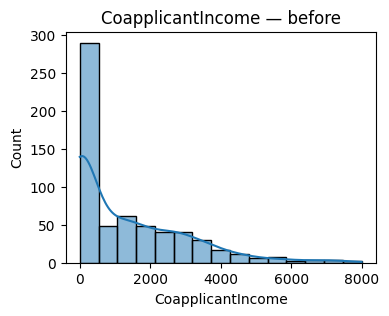

In [76]:
plt.figure(figsize=(4,3))
sns.histplot(df["CoapplicantIncome"], kde=True)
plt.title("CoapplicantIncome — before")
plt.show()

In [77]:
df["CoapplicantIncome"] = np.log1p(df["CoapplicantIncome"])  # log1p handles the zeros safely

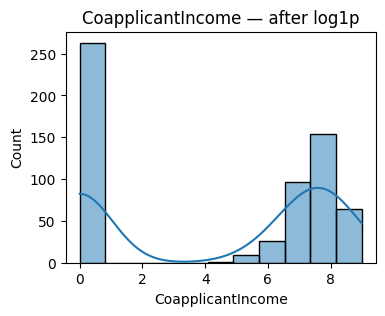

In [78]:
plt.figure(figsize=(4,3))
sns.histplot(df["CoapplicantIncome"], kde=True)
plt.title("CoapplicantIncome — after log1p")
plt.show()

In [79]:
# Power transform (a root, not "exponential") to pull in the right tail of ApplicantIncome
df["ApplicantIncome_power"] = df["ApplicantIncome"] ** (1 / 1.2)

In [80]:
# LoanAmount: a square-root power transform — this part of the original was already fine
df["LoanAmount"] = df["LoanAmount"] ** (1 / 2)

In [81]:
# Box-Cox needs strictly positive values — fine here since Loan_Amount_Term > 0 always
transformed_term, lambda_value = boxcox(df["Loan_Amount_Term"])
print("Lambda value:", lambda_value)

Lambda value: 6.867419559715558


## 9. Train/test split

Do this before scaling (that part of your original was correct for `StandardScaler` — keep
doing it that way for every scaler, which fixes the bug in section 10).

In [82]:
X = df.drop(columns=["Loan_Status (Approved)"])
Y = df["Loan_Status (Approved)"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

## 10. Scaling — fit on train, transform train *and test*, never the target

Your `StandardScaler` cell did this correctly (`fit` on `X_train`, `transform` on both
`X_train` and `X_test`). The `MinMaxScaler` cell, though, had:

```python
X_train_scaled = scaler.fit_transform(X_train)
Y_train_scaled = scaler.transform(Y_test)   # wrong on every level
```

This tries to scale the **target labels** (`Y_test`) using a scaler that was fit on the
**feature matrix** (`X_train`) — wrong variable, wrong axis count, and scaling a
classification target makes no sense in the first place. Below, all three scalers follow the
same, correct pattern: fit on `X_train` only, transform both `X_train` and `X_test`.

In [83]:
standard_scaler = StandardScaler()
standard_scaler.fit(X_train)
X_train_std = standard_scaler.transform(X_train)
X_test_std = standard_scaler.transform(X_test)

In [84]:
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(X_train)
X_train_minmax = minmax_scaler.transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

In [85]:
robust_scaler = RobustScaler()
robust_scaler.fit(X_train)
X_train_robust = robust_scaler.transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

## What was wrong in the original notebook — quick-reference list

| # | Section in your notebook | What was wrong | Fix used above |
|---|---|---|---|
| 1 | Null values | Every missing value filled with a hand-picked constant (`"Male"`, `"Yes"`, `"No"`, `360.0`, `0.0`, `'0'`) instead of a statistic | Mode for categorical / discrete columns, median for continuous `LoanAmount` |
| 2 | Null values (intro markdown) | The "How You Specify a Null Value" text is copy-pasted SQL/Oracle documentation (`NOT NULL`, `CHECK`, `DEPT_HEAD_ID`) and has nothing to do with pandas or this dataset | Removed / not relevant to a pandas feature-engineering workflow |
| 3 | Outliers | "Four ways to identify outliers" is listed but only 3 are given | Minor text fix, not code |
| 4 | Outliers | `ApplicantIncome` was winsorized (capped) but `LoanAmount` outliers were **deleted** (rows dropped) — an inconsistent strategy that also loses data | Cap both columns with the same IQR-based approach |
| 5 | Data Cleaning | `df = df.drop(['Dependents'], axis=1)` deletes the column instead of ordinal-encoding it as the plan said, which is why `df['Dependents'].value_counts()` later crashes with `KeyError` | Ordinal-encode `Dependents`, don't drop it |
| 6 | Preprocessing | `Gender`, `Self_Employed`, `Property_Area` were **never encoded** — planned as one-hot in the markdown but no code ever did it | `pd.get_dummies(...)` on all three, columns kept |
| 7 | Preprocessing | `pd.get_dummies(df, columns=['Married'], ...)` result (`df_encoded`) was computed and then never used again | One-hot/label-encoding results are reassigned back onto `df` and actually used downstream |
| 8 | Preprocessing | `Loan_ID` (a unique identifier — the notebook's own intro says these aren't predictive) was never dropped, and is the direct cause of the `could not convert string to float: 'LP001560'` errors at the very end | Dropped right after loading, before imputation/encoding/scaling |
| 9 | Transformation | `np.log(df['CoapplicantIncome'])` silently produces `-inf` for the many rows where `CoapplicantIncome == 0` | `np.log1p` |
| 10 | Transformation | `ApplicantIncome_exponential` is a fractional-power (root) transform, not an exponential one — the name describes the wrong technique | Renamed to `ApplicantIncome_power`; note that a true exponential transform would increase skew, not reduce it |
| 11 | Scaling | `MinMaxScaler` cell fits on `X_train` but then calls `scaler.transform(Y_test)` — scaling the target with a scaler fit on the features | `scaler.transform(X_test)`, consistent with the other two scalers |
| 12 | Scaling (all three scalers) | All three scaler cells fail with `could not convert string to float` because `Loan_ID`/`Gender`/`Self_Employed`/`Property_Area` were still strings in `X_train` | Resolved once every column is actually encoded (points 5, 6, 8) |